In [2]:
import numpy as np
import matplotlib.pyplot as plt

In [3]:
def phi_i(x, xi, c):
    """φ_i(x) = √(c² + (x − x_i)²)."""
    return np.sqrt(c**2 + (x - xi)**2)

def dphi_i(x, xi, c):
    """First derivative of φ_i."""
    return (x - xi) / np.sqrt(c**2 + (x - xi)**2)

def ddphi_i(x, xi, c):
    """Second derivative of φ_i."""
    return c**2 / (c**2 + (x - xi)**2)**1.5

In [4]:
def H5(z, x1, xN, xi, c):

    del_x = xN - x1                   # shorthand for the interval length

    # Values and derivatives of φ_i at the two end points
    g1   = phi_i (x1, xi, c)
    gN   = phi_i (xN, xi, c)
    g1d  = dphi_i(x1, xi, c)
    gNd  = dphi_i(xN, xi, c)
    g1dd = ddphi_i(x1, xi, c)
    gNdd = ddphi_i(xN, xi, c)

    # Hermite coefficients
    h1 = (gN - g1 - g1d*del_x - 0.5*g1dd*del_x**2) / del_x**3
    h2 = (3*g1 - 3*gN + 2*(g1d + 0.5*gNd)*del_x + 0.5*g1dd*del_x**2) / del_x**4
    h3 = (6*gN - 6*g1 - 3*(g1d + gNd)*del_x + 0.5*(gNdd - g1dd)*del_x**2) / del_x**5

    # Build H5 at the requested point(s) z
    z  = np.asarray(z)                     # supports scalar or array input
    dz = z - x1
    return (g1
            + g1d  * dz
            + 0.5  * g1dd * dz**2
            + h1   * dz**3
            + h2   * dz**3 * (z - xN)
            + h3   * dz**3 * (z - xN)**2)

## Affine map $L_i$ and its inverse

Let

$$
\Delta=\{x_0,x_1,\ldots,x_N\}
$$

be a partition of $I$. For each $i=1,2,\ldots,N$, define an affine map

$$
L_i:I\to I_i=[x_{i-1},x_i]
$$

by

$$
L_i(x)
=
a_i x+b_i,
$$

where

$$
a_i=\frac{x_i-x_{i-1}}{x_N-x_0},
$$

and

$$
b_i=\frac{x_Nx_{i-1}-x_0x_i}{x_N-x_0}.
$$

Thus,

$$
L_i(x_0)=x_{i-1},
\qquad
L_i(x_N)=x_i.
$$

The inverse map is

$$
L_i^{-1}(x)
=
\frac{x-b_i}{a_i},
\qquad x\in [x_{i-1},x_i].
$$

Equivalently,

$$
L_i^{-1}(x)
=
x_0+
\frac{(x-x_{i-1})(x_N-x_0)}{x_i-x_{i-1}}.
$$


In [5]:
def make_L_maps(x_nodes):

    x_nodes = np.asarray(x_nodes, dtype=float)
    x0 = x_nodes[0]
    xN = x_nodes[-1]
    N = len(x_nodes) - 1

    a = np.empty(N)
    b = np.empty(N)

    for i in range(N):
        a[i] = (x_nodes[i+1] - x_nodes[i]) / (xN - x0)
        b[i] = (xN * x_nodes[i] - x0 * x_nodes[i+1]) / (xN - x0)

    return a, b


def L_inverse(x, i, a, b):

    return (x - b[i]) / a[i]

# Build the alpha-fractal function of $\phi_{i}(x)$ numerically

The $\alpha$-fractal function associated with $f$, the base function $g$, the partition $\Delta$, and the scale vector $\alpha$ is the unique continuous function

$$
f^\alpha:I\to \mathbb{R}
$$

$$
f^\alpha(x)
=
f(x)
+
\alpha_i
\left[
f^\alpha\left(L_i^{-1}(x)\right)
-
g\left(L_i^{-1}(x)\right)
\right],
\qquad
x\in [x_{i-1},x_i],
$$

for every

$$
i=1,2,\ldots,N.
$$

Equivalently,

$$
f^\alpha(L_i(x))
=
f(L_i(x))
+
\alpha_i
\left[
f^\alpha(x)-g(x)
\right],
\qquad x\in I.
$$


In [6]:

def phi_alpha_fractal(x_eval, x_nodes, alpha, xi, c, max_iter=500, tol=1e-10):
    
    x_eval = np.asarray(x_eval, dtype=float)
    x_nodes = np.asarray(x_nodes, dtype=float)
    alpha = np.asarray(alpha, dtype=float)

    x0 = x_nodes[0]
    xN = x_nodes[-1]
    N = len(x_nodes) - 1

    if len(alpha) != N:
        raise ValueError("alpha must have length N = len(x_nodes) - 1")

    if np.max(np.abs(alpha)) >= 1:
        raise ValueError("Need ||alpha||_inf < 1 for contraction.")

    # affine coefficients
    a, b = make_L_maps(x_nodes)

    # original function f and base function g
    def f(x):
        return phi_i(x, xi, c)

    def g(x):
        return H5(x, x0, xN, xi, c)

    # initial guess: start with f
    phi_vals = f(x_eval).copy()

    # fixed-point iteration
    for _ in range(max_iter):
        new_vals = np.empty_like(phi_vals)

        for j, x in enumerate(x_eval):
            # determine subinterval [x_{i}, x_{i+1}] containing x
            # i is 0-based
            if x == x_nodes[-1]:
                i = N - 1
            else:
                i = np.searchsorted(x_nodes, x, side='right') - 1
                i = min(max(i, 0), N - 1)

            x_pre = L_inverse(x, i, a, b)

            # We need phi_n evaluated at x_pre.
            # Since phi_vals is only known on x_eval, interpolate.
            phi_pre = np.interp(x_pre, x_eval, phi_vals)

            new_vals[j] = f(x) + alpha[i] * (phi_pre - g(x_pre))

        err = np.max(np.abs(new_vals - phi_vals))
        phi_vals = new_vals

        if err < tol:
            break

    return phi_vals

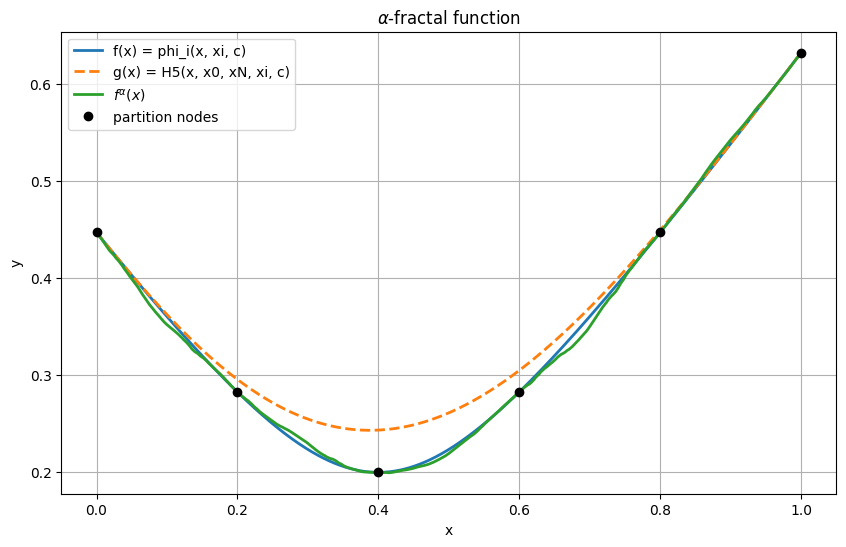

In [7]:
import matplotlib.pyplot as plt

# Example partition
x_nodes = np.linspace(0.0, 1.0, 6)   # [x0, x1, ..., xN]
alpha = np.array([0.2, -0.15, 0.1, 0.25, -0.1])

# Parameters used in phi_i and H5
xi = 0.4
c = 0.2

# Evaluation grid
x_eval = np.linspace(x_nodes[0], x_nodes[-1], 2000)

# Compute functions
f_vals = phi_i(x_eval, xi, c)
g_vals = H5(x_eval, x_nodes[0], x_nodes[-1], xi, c)
fa_vals = phi_alpha_fractal(x_eval, x_nodes, alpha, xi, c)

# Plot
plt.figure(figsize=(10, 6))
plt.plot(x_eval, f_vals, label='f(x) = phi_i(x, xi, c)', linewidth=2)
plt.plot(x_eval, g_vals, label='g(x) = H5(x, x0, xN, xi, c)', linewidth=2, linestyle='--')
plt.plot(x_eval, fa_vals, label=r'$f^\alpha(x)$', linewidth=2)

plt.plot(x_nodes, phi_i(x_nodes, xi, c), 'ko', label='partition nodes')
plt.legend()
plt.xlabel('x')
plt.ylabel('y')
plt.title(r'$\alpha$-fractal function')
plt.grid(True)
plt.show()